##### ========================================================================================================================
### 1. IMPORT LIBRARIES
##### ========================================================================================================================

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import statsmodels.formula.api as smf
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
import ast

##### ========================================================================================================================
### 2. Define Data Path & Import Data
##### ========================================================================================================================

In [2]:
data_dir = Path("Utility/Data/PData5")

files = sorted(data_dir.glob("*.csv"))

print("Files found:")
for f in files:
    print(f.name)

dfs = []

for f in files:
    df = pd.read_csv(f)
    df["source_file"] = f.name
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

Files found:
dcl-retrospectivedurationjudgement-oliver-esnorming_101.csv
dcl-retrospectivedurationjudgement-oliver-esnorming_102.csv
dcl-retrospectivedurationjudgement-oliver-esnorming_66 (1).csv
dcl-retrospectivedurationjudgement-oliver-esnorming_68 (1).csv
dcl-retrospectivedurationjudgement-oliver-esnorming_70.csv
dcl-retrospectivedurationjudgement-oliver-esnorming_78.csv
dcl-retrospectivedurationjudgement-oliver-esnorming_80.csv
dcl-retrospectivedurationjudgement-oliver-esnorming_83.csv
dcl-retrospectivedurationjudgement-oliver-esnorming_84.csv
dcl-retrospectivedurationjudgement-oliver-esnorming_85.csv
dcl-retrospectivedurationjudgement-oliver-esnorming_90.csv
dcl-retrospectivedurationjudgement-oliver-esnorming_91.csv
dcl-retrospectivedurationjudgement-oliver-esnorming_95.csv


##### ========================================================================================================================
### 3. Data Cleaning
##### ========================================================================================================================

In [3]:
# Keep only real segmentation video trials
Pilot5_data = data[data["trial_kind"] == "segmentation_video"].copy()

Pilot5_data.head()

#Remove Demo Trail
Pilot5_data = Pilot5_data[
    Pilot5_data["predictability"] != "Demo"].copy()

# Keep only the varaibles I need
keep_cols = [
    "PROLIFIC_PID",
    "randomized_pair_order",
    "stimulus_name",
    "predictability",
    "boundary_times_sec",
    "boundary_count",
    "block",
    "global_position_in_block",
    "video_attention_failure_type"
]

Pilot5_data = Pilot5_data[keep_cols].copy()
Pilot5_data = Pilot5_data.reset_index(drop=True)


#Remove Attention Violation Trails
Pilot5_data = Pilot5_data[
    Pilot5_data["video_attention_failure_type"].isna()
].copy()

##### ========================================================================================================================
### 4. Regression on NoB in Predictability Conditions
##### ========================================================================================================================

In [4]:
# Make sure predictability is categorical
Pilot5_data["predictability"] = (Pilot5_data["predictability"].astype("category"))

# Linear regression
model = smf.ols("boundary_count ~ predictability",data=Pilot5_data).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         boundary_count   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7493
Date:                Mon, 08 Jun 2026   Prob (F-statistic):              0.387
Time:                        21:57:07   Log-Likelihood:                -2360.6
No. Observations:                 772   AIC:                             4725.
Df Residuals:                     770   BIC:                             4734.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

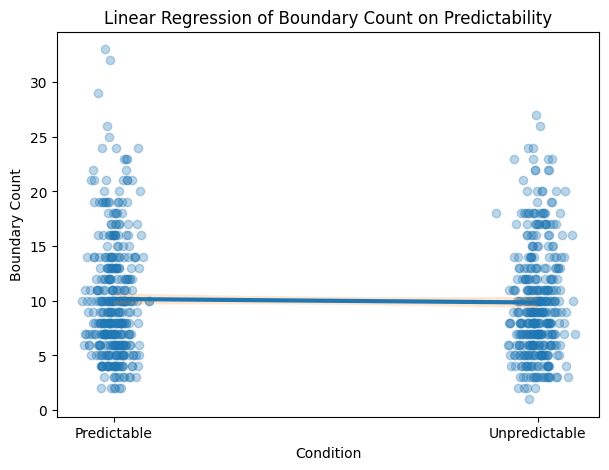

In [5]:
# Plot for Regression

# Fit regression
Pilot5_data["predictability_num"] = Pilot5_data["predictability"].map({"Predictable": 0, "Unpredictable": 1 }).astype(float)

Pilot5_data["boundary_count"] = pd.to_numeric(Pilot5_data["boundary_count"], errors="coerce")

Pilot5_data = Pilot5_data.dropna(subset=["predictability_num", "boundary_count"]).copy()

model = smf.ols("boundary_count ~ predictability_num", data=Pilot5_data).fit()

x_pred = np.linspace(0, 1, 100)

pred_df = pd.DataFrame({"predictability_num": x_pred})

pred_summary = model.get_prediction(pred_df).summary_frame(alpha=0.05)

plt.figure(figsize=(7,5))

x_jitter = (Pilot5_data["predictability_num"] + np.random.normal(0, 0.03, len(Pilot5_data)))

plt.scatter(x_jitter, Pilot5_data["boundary_count"], alpha=0.3)
plt.plot(x_pred, pred_summary["mean"], linewidth=3)
plt.fill_between(x_pred, pred_summary["mean_ci_lower"], pred_summary["mean_ci_upper"], alpha=0.2 )
plt.xticks([0, 1], ["Predictable", "Unpredictable"])
plt.xlabel("Condition")
plt.ylabel("Boundary Count")
plt.title("Linear Regression of Boundary Count on Predictability")
plt.show()

##### ========================================================================================================================
### 5. Boundary Consensus
##### ========================================================================================================================

In [6]:
# Video Duration Dictionary
video_durations = {
    "baking": 28.75,
    "balcony": 28.00,
    "bank": 19.11,
    "bathroom": 35.11,
    "beach": 26.75,
    "bedding": 34.68,
    "bike": 29.31,
    "car": 39.44,
    "cleaning": 30.00, 
    "cereal": 37.71,
    "fireplace": 30.99,
    "football": 36.00,
    "gym": 29.31,
    "lamp": 29.52,
    "laundry": 30.84,
    "mouse": 29.76,
    "music": 38.12,
    "painting": 24.55,
    "party": 35.17,
    "poster": 23.53,
    "printer": 44.05,
    "record": 19.11,
    "shopping": 11.79,
    "skateboard": 24.12,
    "suitcase": 27.15,
    "sunbathing": 40.12,
    "tea": 31.00, 
    "tennis": 29.76,
    "walking": 21.52,
    "whiteboard": 36.54,
}

In [30]:
# Parse the Boundary List
def parse_boundary_times(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return []

Pilot5_data["boundary_times_list"] = (Pilot5_data["boundary_times_sec"].apply(parse_boundary_times))


# Parameters 
BIN_SIZE = 0.1
SMOOTH_SIGMA = 4

PEAK_PROMINENCE = 1
PEAK_DISTANCE = 3

# Create an aggregated boundary timeline per video
def make_boundary_vector(boundary_times, duration, bin_size=0.1):
    bins = np.arange(0, duration + bin_size, bin_size)
    counts, _ = np.histogram(boundary_times, bins=bins)
    return counts, bins[:-1]

In [31]:
# BUILD CONSENSUS TIMELINES BY VIDEO × CONDITION

all_video_results = {}
group_cols = ["stimulus_name", "predictability"]

for (stimulus_name, predictability), df_vid in Pilot5_data.groupby(group_cols):
    duration = video_durations[stimulus_name]
    all_boundaries = []

    #Aggregate all participant timestamps
    for boundary_list in df_vid["boundary_times_list"]:
        all_boundaries.extend(boundary_list)

    bins = np.arange(0,duration + BIN_SIZE,BIN_SIZE)
    counts, edges = np.histogram(all_boundaries,bins=bins)
    time_axis = edges[:-1]
    n_trials = len(df_vid)

    #Normalize it under the density function of 1
    consensus = counts / n_trials

    #Smooth the temporal density
    smoothed_consensus = gaussian_filter1d(
        consensus,
        sigma=SMOOTH_SIGMA
    )


    # Detect peaks
    peaks, properties = find_peaks(
        smoothed_consensus,
        prominence=PEAK_PROMINENCE / n_trials,
        distance=PEAK_DISTANCE
    )

    peak_times = time_axis[peaks]

    #Store Output
    all_video_results[(stimulus_name, predictability)] = {
        "stimulus_name": stimulus_name,
        "predictability": predictability,
        "time_axis": time_axis,
        "raw_counts": counts,
        "consensus": consensus,
        "smoothed_consensus": smoothed_consensus,
        "peak_indices": peaks,
        "peak_times": peak_times,
        "peak_heights": smoothed_consensus[peaks],
        "all_boundaries": all_boundaries,
        "n_trials": n_trials
    }

/var/folders/dq/9p1h0c_51bg_hq6bmswn7y4c0000gn/T/ipykernel_65394/2720606112.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (stimulus_name, predictability), df_vid in Pilot5_data.groupby(group_cols):


In [32]:
# Function of Creating the Plot of the Aggregate Timeline
def plot_consensus_by_condition(video_name):

    plt.figure(figsize=(14, 5))

    for condition in ["Predictable", "Unpredictable"]:

        key = (video_name, condition)

        if key not in all_video_results:
            print(f"Missing result for {video_name} | {condition}")
            continue

        res = all_video_results[key]

        plt.plot(res["time_axis"], res["smoothed_consensus"], linewidth=2, label=f"{condition} consensus")
        plt.scatter(res["peak_times"], res["peak_heights"], s=70, label=f"{condition} peaks")
        
    plt.xlabel("Time in Video (seconds)")
    plt.ylabel("Boundary Consensus")
    plt.title(f"Group Consensus Timeline by Condition: {video_name}")
    plt.legend()
    plt.show()

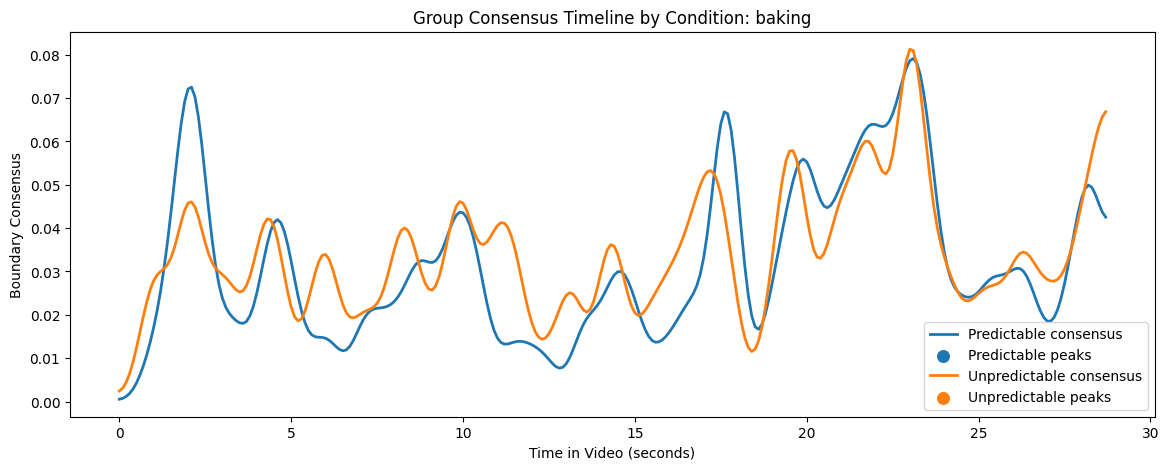

In [33]:
plot_consensus_by_condition("baking")

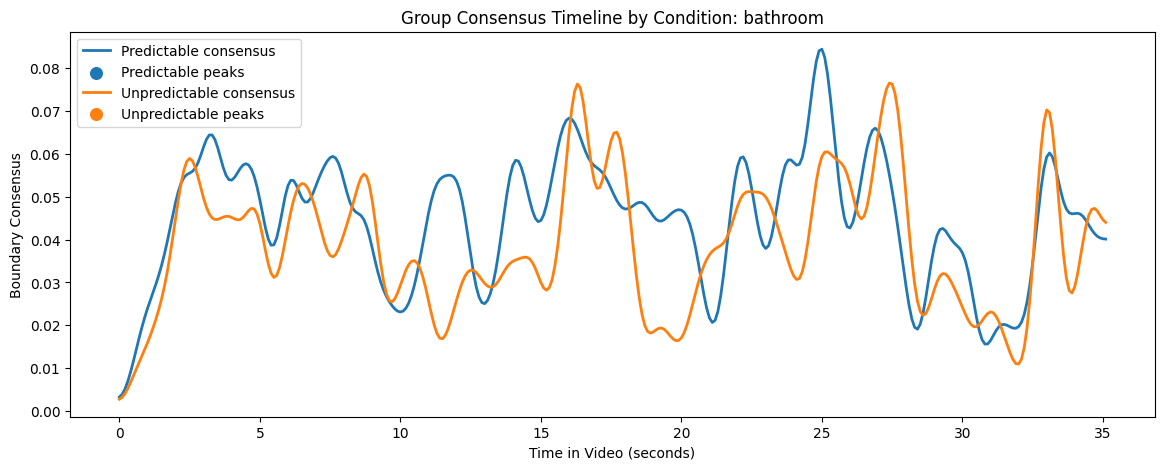

In [34]:
plot_consensus_by_condition("bathroom")

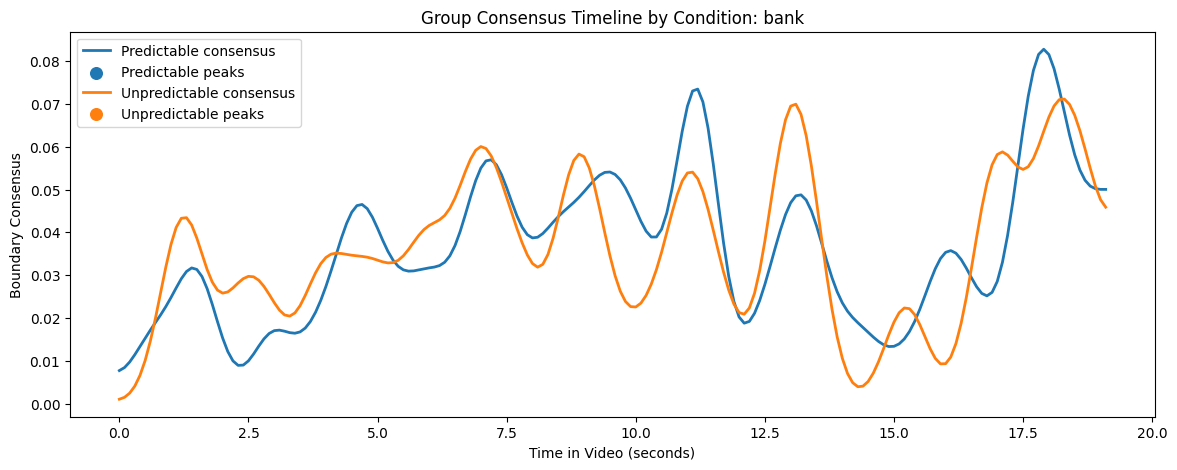

In [35]:
plot_consensus_by_condition("bank")

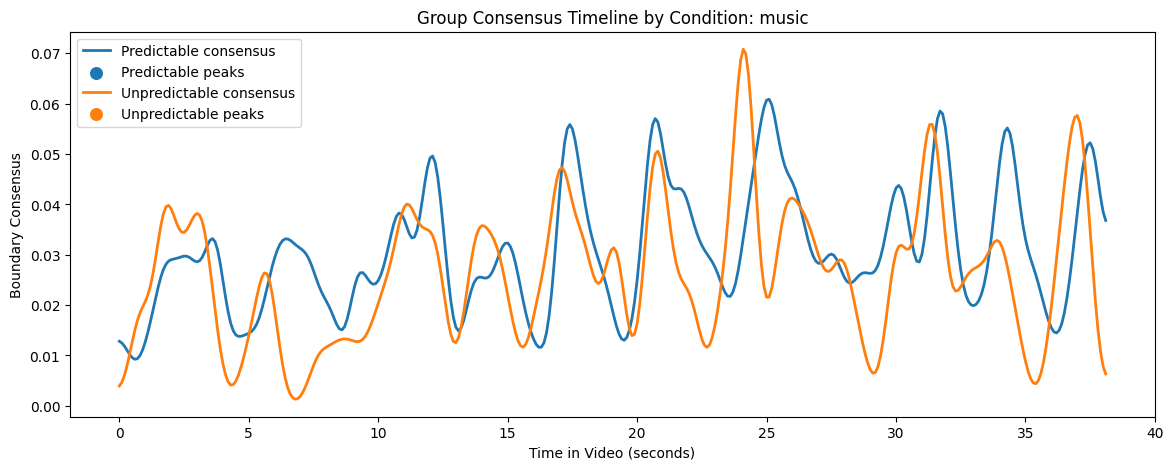

In [36]:
plot_consensus_by_condition("music")

In [12]:
# ============================================================
# 5. Check the First Few Boundries
# ============================================================